## Collect & Prepare Your Own Documents

Task:

1. Create a folder named my_docs/.
2. Place at least 3 text-based files in it — .txt, .md, or extracted .pdf text.
  
Examples:
  - A research paper summary you wrote
  - A blog article about AI or sustainability
  - Course notes or company reports

3. Load them into Python.

In [1]:
pip install pypdf


Note: you may need to restart the kernel to use updated packages.


In [2]:
from pypdf import PdfReader
import os
folder = "my_docs"
documents = []

for file in os.listdir(folder):
    if file.endswith(".pdf"):
        path = os.path.join(folder, file)
        reader = PdfReader(path)
        text = ""
        for page in reader.pages:
            text += page.extract_text() or ""
        documents.append(text)

print(f"Loaded {len(documents)} documents.")
print(documents[0][:300])


Loaded 3 documents.
Praise	for	
Learning	LangChain
With	clear	explanations	and	actionable	techniques,	this	is	the	go-to
resource	for	anyone	looking	to	harness	LangChain’s	power	for	production-
ready	generative	AI	and	agents.	
A	must-read
	for	developers	aiming	to	push
the	boundaries	of	this	platform.
—
Tom	Taulli,	IT	c


## Chunk Your Texts

**Goal**: Break long text into manageable pieces for retrieval.

In [3]:
def chunk_text(text, chunk_size=400):
    words = text.split()
    return [" ".join(words[i:i+chunk_size]) for i in range(0, len(words), chunk_size)]

chunks = []
for doc in documents:
    chunks.extend(chunk_text(doc))

print("Total chunks created:", len(chunks))


Total chunks created: 934


## Build Your Own Retriever (Semantic)

**Goal**: Retrieve the most relevant chunks using embeddings.

In [4]:
# !pip install sentence-transformers

In [5]:
from sentence_transformers import SentenceTransformer, util
import torch

embedder = SentenceTransformer("all-MiniLM-L6-v2")

# TODO: Embed your chunks
chunk_embeddings = embedder.encode(chunks, convert_to_tensor=True)

def retrieve_chunks(query, k=2):
    query_embed = embedder.encode(query, convert_to_tensor=True)
    scores = util.cos_sim(query_embed, chunk_embeddings)[0]
    top_k = torch.topk(scores, k)
    return [chunks[i] for i in top_k.indices]

# TEST
print(retrieve_chunks("What is discussed about Langchain?", k=2))


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

['Media, Inc. 1005 Gravenstein Highway North Sebastopol, CA 95472 800-889-8969 (in the United States or Canada) 707-827-7019 (international or local) 707-829-0104 (fax) support@oreilly.com https://oreilly.com/about/contact.html We have a web page for this book, where we list errata, examples, and any additional information. You can access this page at https://oreil.ly/learning- langchain . For news and information about our books and courses, visit https://oreilly.com . Find us on LinkedIn: https://linkedin.com/company/oreilly-media . Watch us on YouTube: https://youtube.com/oreillymedia . Acknowledgments We would like to express our gratitude and appreciation to the reviewers—Rajat Kant Goel, Douglas Bailley, Tom Taulli, Gourav Bais, and Jacob Lee—for providing valuable technical feedback on improving this book. Tom B. Brown et al., “Language Models Are Few-Shot Learners” , arXiv, July 22, 2020. Xiang Zhang et al., “Don’t Trust ChatGPT When Your Question Is Not in English: A Study of 

## Connect Retrieval with Generation

**Goal**: Use retrieved chunks as context for text generation.

In [6]:
from transformers import pipeline

generator = pipeline("text-generation", model="distilgpt2", max_new_tokens=100, temperature=0.3, truncation=True)

def mini_rag(query, k=1):
    retrieved = retrieve_chunks(query, k)
    context = "\n".join(retrieved)
    prompt = f"Use the following context to answer the question:\n\n{context}\n\nQuestion: {query}\n\nAnswer:"
    return generator(prompt)[0]['generated_text']

# TODO: Try 2–3 questions based on your own documents
#Observe how the generator uses their context.
# Run the same question with and without retrieval.
# Compare and describe differences.
print(mini_rag("Summarize the main idea from my document."))


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_

Use the following context to answer the question:

Now you have something you can see that describes “something” about the two docu- ments and their relationship to the word “dog” and each other. So instead of raw word counts to describe your documents in a corpus, you can use normalized term frequen- cies. Similarly you could calculate each word and get the relative importance to the document of that term. Your protagonist, Harry, and his need for speed are clearly central to the story of this document. You’ve made some great progress in turning text into numbers, beyond just the presence or absence of a given word. Now this is a clearly contrived example, but you can quickly see how meaningful results could come from this approach. Let’s look at a bigger piece of text. Take these first few paragraphs from the Wikipedia article on kites: A kite is traditionally a tethered heavier-than-air craft with wing surfaces that react against the air to create lift and drag. A kite consists of w

## Add a LangChain RAG Chain

**Goal**: Chain the retrieval and generation steps modularly.

In [7]:
# pip install langchain

In [8]:
# pip install -U langchain

In [9]:
# !pip show langchain langchain-core

In [10]:
# !pip install langchain-huggingface

In [11]:
# def get_context(q, k=3):  # bumped to top 3 per the TODO
#     chunks = retrieve_chunks(q, k)
#     print("Retrieved chunks:")
#     for i, c in enumerate(chunks):
#         print(f"[{i}] {c[:200]}...")
#     return "\n".join(chunks)

# rag_chain = (
#     {"context": lambda q: get_context(q, 3), "question": RunnablePassthrough()}
#     | prompt
#     | llm
# )

# print(rag_chain.invoke("What are the key challenges mentioned in my research?"))

In [12]:
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_huggingface import HuggingFacePipeline   # separate package, may need: pip install langchain-huggingface
# from langchain.chains import LLMChain  
def get_context(q, k=3):  # bumped to top 3 per the TODO
    chunks = retrieve_chunks(q, k)
    print("Retrieved chunks:")
    for i, c in enumerate(chunks):
        print(f"[{i}] {c[:200]}...")
    return "\n".join(chunks)

llm = HuggingFacePipeline(pipeline=generator)

prompt = ChatPromptTemplate.from_template("""
Context:
{context}

Question:
{question}

Answer clearly and concisely:
""")

rag_chain = (
    {"context": lambda q: "\n".join(retrieve_chunks(q, 2)), "question": RunnablePassthrough()}
    | prompt
    | llm
)

# TODO: Run your chain
# Modify the retriever to return top 3 instead of 2.
# Print retrieved chunks before answering.
# Discuss if adding more chunks improved or worsened quality.
print(rag_chain.invoke("What are the key challenges mentioned in my research?"))


[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] This is a friendly reminder - the current text generation call has exceeded the model's predefined maximum length (1024). Depending on the model, you may observe exceptions, performance degradation, or nothing at all.


Human: 
Context:
nurturing connections, and understanding human relationships, consider delving deeper into each of these themes. Provide specific examples from the book to support your points and explore how these themes manifest in contemporary life.\n\n2. **Analysis**: Consider analyzing how the book\'s messages can be applied to current societal issues or personal experiences. For instance, you could discuss how the Little Prince\'s perspective on materialism relates to consumer culture or explore how his approach to relationships can inform interpersonal dynamics in the digital age.\n\n3. **Length**: Expand on your ideas by adding more examples, discussing counterarguments, or exploring the cultural impact of "The Little Prince" in different parts of the world. This will enrich the depth of your analysis and provide a more comprehensive understanding of the book\'s relevance.\n\n4. **Style**: Your essay is clear and well-structured. To enhance the engagement of your readers, consi

## Evaluation & Reflection

### Goal
Critically assess and document the performance of **your own RAG system**.  
Reflect on how your retrieval and generation pipeline behaved with your chosen documents.

---

### Evaluation Questions

| **Question** | **Students Write** |
|---------------|--------------------|
| **How many documents did you use?** |  3 PDF |
| **What type of content (topic/domain)?** | About NLP,Langchain |
| **Which retrieval size (chunk length, `top_k`) worked best?** | I used k=2 and chunk = 200 and 400.Based on the token-limit truncation issue I ran into, I'd expect 200 to retrieve more complete chunks within distilgpt2's context window.  |
| **Did the model produce hallucinations? When?** |  Not hallucination in the sense of inventing false facts.distilgpt2 repeated the question back as the answer rather than generating new content.|
| **What improvement would you try next?** |  I will try to use a different model since the recommended model is not giving proper text.|

---

### Home Assignment

- **Try another model**, e.g. `google/flan-t5-base` or `facebook/bart-large`, and compare outputs.  
- **Visualize cosine similarity scores** between your query and retrieved chunks as a bar chart to better understand retrieval ranking.

---




In [13]:
from transformers import pipeline

flan_generator = pipeline(
    "text-generation",
    model="google/flan-t5-base",
    max_new_tokens=100,
)

def mini_rag_flan(query, k=2):
    retrieved = retrieve_chunks(query, k)
    context = "\n".join(retrieved)
    prompt = f"Use the following context to answer the question.\n\nContext:\n{context}\n\nQuestion: {query}\n\nAnswer:"
    output = flan_generator(prompt)[0]['generated_text']
    return output

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCa

In [14]:
flan_generator = pipeline(
    "text-generation",
    model="google/flan-t5-base",
    max_new_tokens=100,
    truncation=True,
)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'Cohere2MoeForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM',

In [15]:
import torch

def plot_similarity_scores(query, k=5):
    query_embed = embedder.encode(query, convert_to_tensor=True)
    scores = util.cos_sim(query_embed, chunk_embeddings)[0]
    top_k = torch.topk(scores, k)

    labels = [f"Chunk {i}" for i in top_k.indices.tolist()]
    values = [round(s, 3) for s in top_k.values.tolist()]

    print("Top chunks and scores:")
    for i, (idx, score) in enumerate(zip(top_k.indices.tolist(), values)):
        preview = chunks[idx][:100].replace("\n", " ")
        print(f"{i}: score={score:.3f}  |  {preview}...")

    return labels, values

labels, values = plot_similarity_scores("What are the key challenges mentioned in my research?", k=5)

Top chunks and scores:
0: score=0.327  |  nurturing connections, and understanding human relationships, consider delving deeper into each of t...
1: score=0.292  |  documents to build its common sense knowledge about the world. SENTENCE SEGMENTATION Sentence segmen...
2: score=0.283  |  the model) which text is most relevant to answer each question? In this chapter and the next, you’ll...
3: score=0.280  |  models specialize in other domains, like programming. These models tend to be evaluated on different...
4: score=0.266  |  resources yourself simply by entering the heading text into a semantic search engine like Duck Duck ...


Top chunks and scores:
0: score=0.327  |  nurturing connections, and understanding human relationships, consider delving deeper into each of t...
1: score=0.292  |  documents to build its common sense knowledge about the world. SENTENCE SEGMENTATION Sentence segmen...
2: score=0.283  |  the model) which text is most relevant to answer each question? In this chapter and the next, you’ll...
3: score=0.280  |  models specialize in other domains, like programming. These models tend to be evaluated on different...
4: score=0.266  |  resources yourself simply by entering the heading text into a semantic search engine like Duck Duck ...


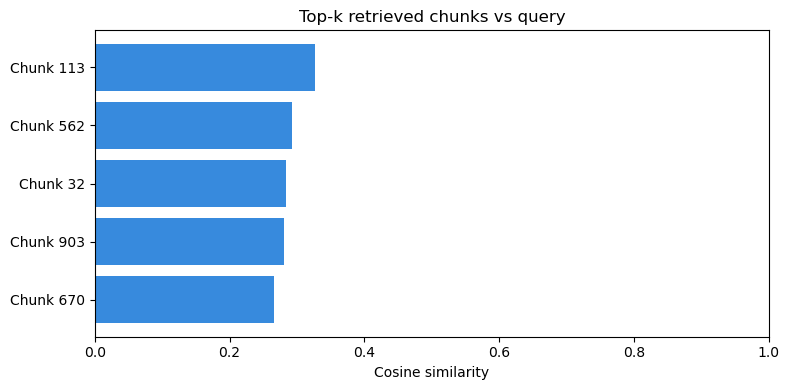

In [16]:
import matplotlib.pyplot as plt

labels, values = plot_similarity_scores("What are the key challenges mentioned in my research?", k=5)

plt.figure(figsize=(8, 4))
plt.barh(labels[::-1], values[::-1], color="#378ADD")
plt.xlabel("Cosine similarity")
plt.xlim(0, 1)
plt.title("Top-k retrieved chunks vs query")
plt.tight_layout()
plt.show()